In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

In [46]:
df = pd.read_csv("globallink_operations.csv")

Exploratory Data Analysis


In [47]:

df.describe()

,process_time_mins,rework_time_mins,total_time_mins,labor_cost_per_hour,defect_flag,rework_cost,delay_cost
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,14.619540,1.052900,15.672505,37.402025,0.152000,0.654665,0.722165
std,5.062972,2.686395,6.609080,7.207421,0.359111,1.706950,1.901108
min,5.000000,0.000000,5.000000,25.000000,0.000000,0.000000,0.000000
25%,11.247500,0.000000,11.452500,31.030000,0.000000,0.000000,0.000000
50%,13.505000,0.000000,13.895000,37.320000,0.000000,0.000000,0.000000
75%,16.612500,0.000000,17.907500,43.560000,0.000000,0.000000,0.272500
max,43.870000,15.520000,54.320000,50.000000,1.000000,11.840000,20.800000


In [48]:


# 1. Ensure pandas recognizes the columns as actual dates/times
df['timestamp_start'] = pd.to_datetime(df['timestamp_start'])

# 2. Pull the exact hour out of your starting timestamp
df['hour'] = df['timestamp_start'].dt.hour

# 3. Re-assign the correct shifts based on standard factory hours
# This sets Day shift from 06:00 to 17:59 (Hours 6 to 17)
# All other hours (18:00 to 05:59) become Night shift
df['shift'] = np.where((df['hour'] >= 6) & (df['hour'] < 18), 'Day', 'Night')

# 4. Verify it worked by printing a count
print(df.groupby(['shift', 'hour']).size())


shift  hour
Day    6       90
       7       90
       8       90
       9       90
       10      90
       11      90
       12      90
       13      90
       14      90
       15      90
       16      90
       17      90
Night  0       80
       1       60
       2       60
       3       60
       4       60
       5       60
       18      90
       19      90
       20      90
       21      90
       22      90
       23      90
dtype: int64


In [49]:
df.shape

(2000, 14)

In [50]:
df.dtypes

order_id                       object
timestamp_start        datetime64[ns]
timestamp_end                  object
station_id                     object
shift                          object
process_time_mins             float64
rework_time_mins              float64
total_time_mins               float64
labor_cost_per_hour           float64
defect_flag                     int64
status                         object
rework_cost                   float64
delay_cost                    float64
hour                            int32
dtype: object

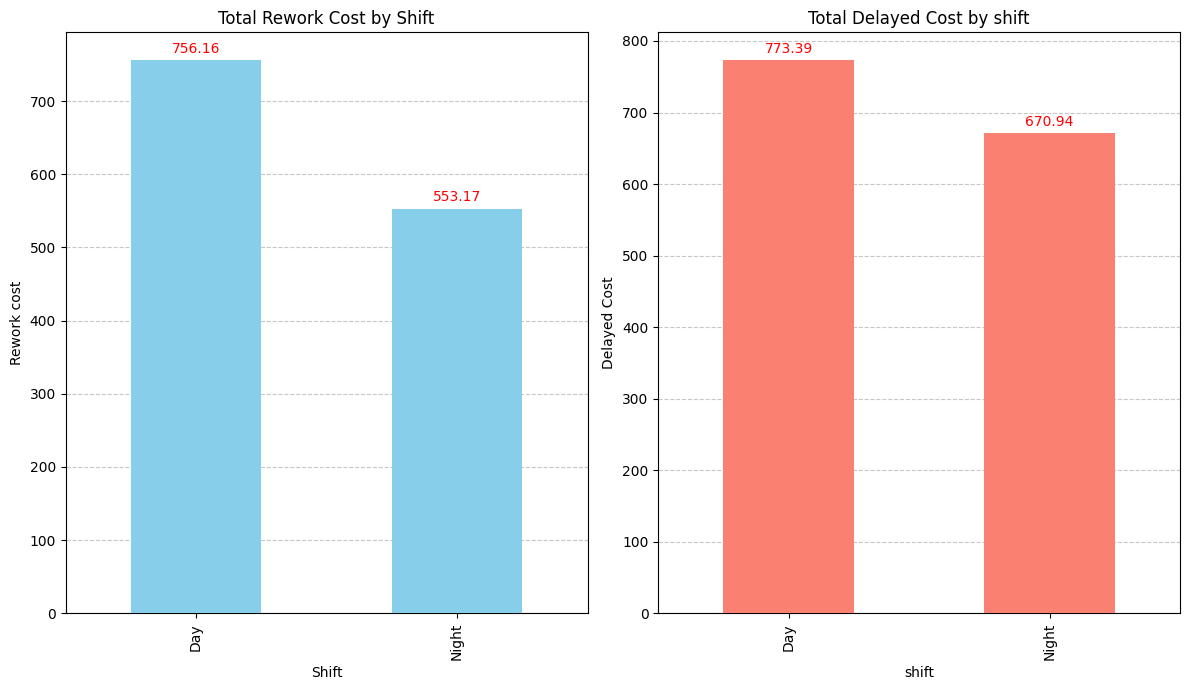

In [51]:
# Rework and delayed cost by shifts
shift_rework_cost = df.groupby("shift")["rework_cost"].sum()
shift_delayed_cost = df.groupby("shift")["delay_cost"].sum()
# Plotting the results
plt.figure(figsize=(12,7))
plt.subplot(1, 2, 1)
shift_rework_cost.plot(kind = 'bar',color ='skyblue', zorder=3)
plt.title("Total Rework Cost by Shift")
plt.xlabel("Shift")
plt.ylabel("Rework cost")
plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
for container in plt.gca().containers:
    plt.bar_label(container,fmt = '%.2f', padding = 3,color = "red")

plt.subplot(1, 2, 2)
shift_delayed_cost.plot(kind = "bar",color="salmon", zorder=3)
plt.title("Total Delayed Cost by shift")
plt.xlabel("shift")
plt.ylabel("Delayed Cost")
plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
for container in plt.gca().containers:
    plt.bar_label(container,fmt = '%.2f', padding = 3,color = "red")

plt.tight_layout()
plt.show()

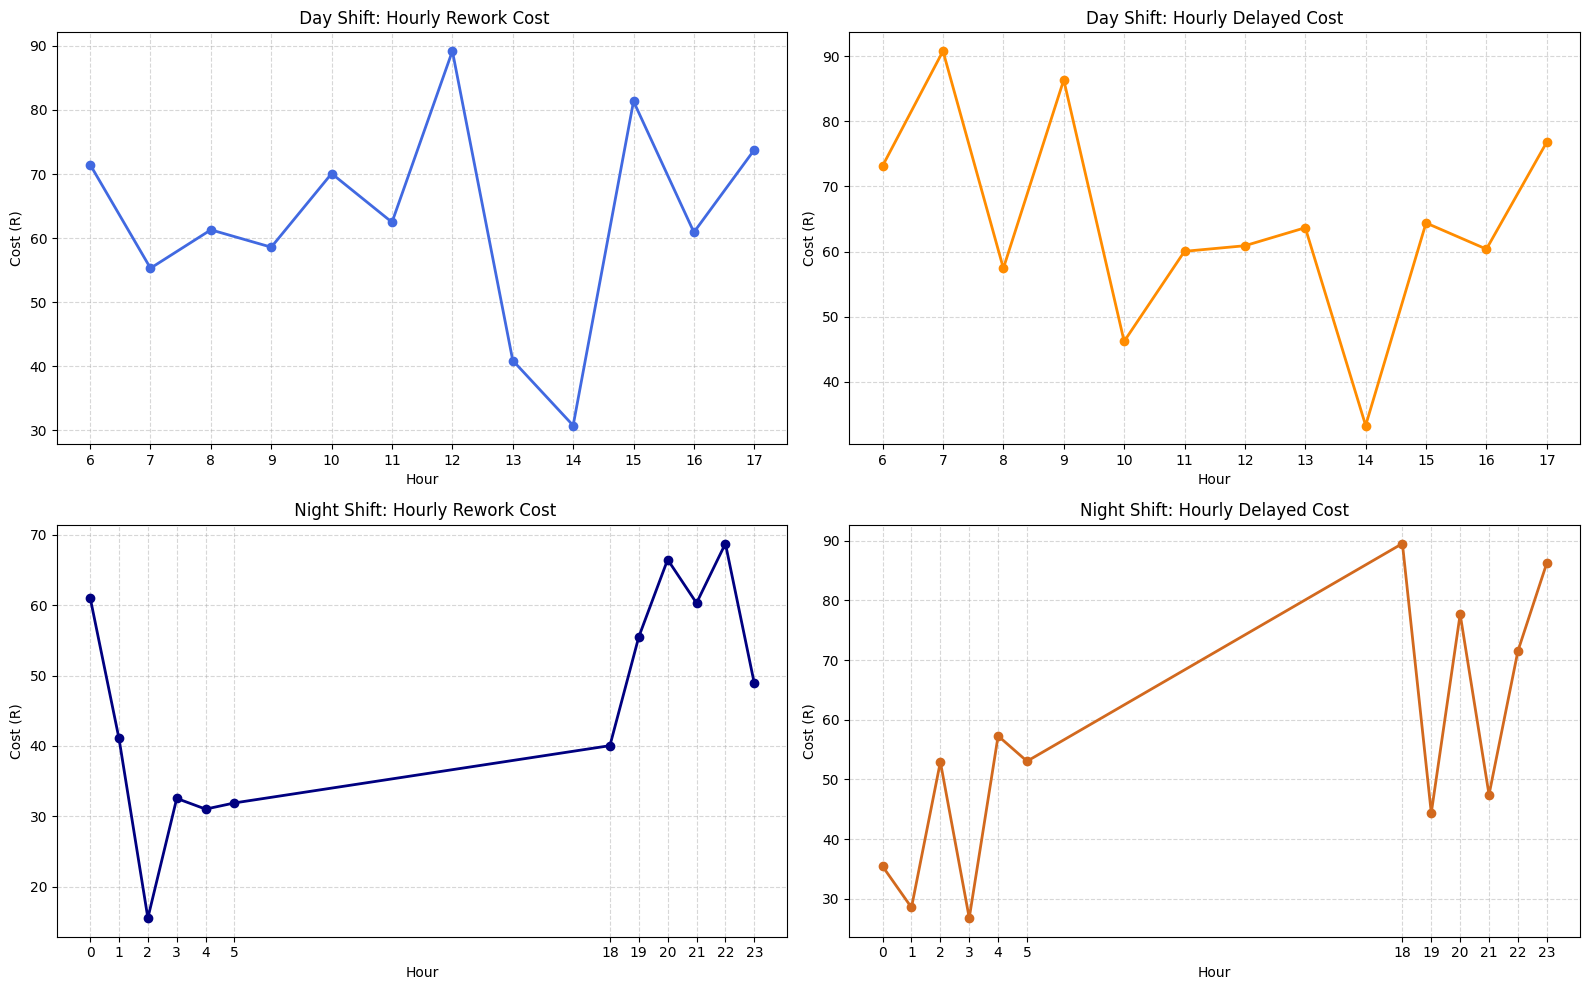

In [52]:
# peak hour/shift analysis

# 1. Filter the data into Day and Night dataframes
day_df = df[df['shift'] == 'Day']
night_df = df[df['shift'] == 'Night']

# 2. Group each by hour
day_rework = day_df.groupby('hour')['rework_cost'].sum()
day_delay = day_df.groupby('hour')['delay_cost'].sum()

night_rework = night_df.groupby('hour')['rework_cost'].sum()
night_delay = night_df.groupby('hour')['delay_cost'].sum()

# 3. Create a clean 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ROW 1: DAY SHIFT (Hours 6 to 17) 
# Chart 1: Day Rework
day_rework.plot(kind='line', marker='o', color='royalblue', linewidth=2, ax=axes[0, 0])
axes[0, 0].set_title(" Day Shift: Hourly Rework Cost")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Cost (R)")
axes[0, 0].set_xticks(range(6, 18))
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Chart 2: Day Delay
day_delay.plot(kind='line', marker='o', color='darkorange', linewidth=2, ax=axes[0, 1])
axes[0, 1].set_title("Day Shift: Hourly Delayed Cost")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Cost (R)")
axes[0, 1].set_xticks(range(6, 18))
axes[0, 1].grid(True, linestyle='--', alpha=0.5)


# ROW 2: NIGHT SHIFT (Hours 18 to 23, 0 to 5)

# Chart 3: Night Rework
night_rework.plot(kind='line', marker='o', color='navy', linewidth=2, ax=axes[1, 0])
axes[1, 0].set_title(" Night Shift: Hourly Rework Cost")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("Cost (R)")
# Night hours wrap around midnight, so we list them explicitly
axes[1, 0].set_xticks([18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5])
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Chart 4: Night Delay
night_delay.plot(kind='line', marker='o', color='burntorange' if 'burntorange' in plt.colormaps else 'chocolate', linewidth=2, ax=axes[1, 1])
axes[1, 1].set_title("Night Shift: Hourly Delayed Cost")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_ylabel("Cost (R)")
axes[1, 1].set_xticks([18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5])
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Data Integrity Note

During Peak Hour Analysis, a timestamp-shift misalignment was 
identified in the original dataset. Shifts were reassigned based 
on actual timestamps:
- Day Shift: 06:00 – 17:00
- Night Shift: 18:00 – 05:00

This correction significantly impacted shift-based analysis, 
shifting the primary bottleneck from Night to Day operations. 
This highlights the critical importance of data validation 
before drawing business conclusions.

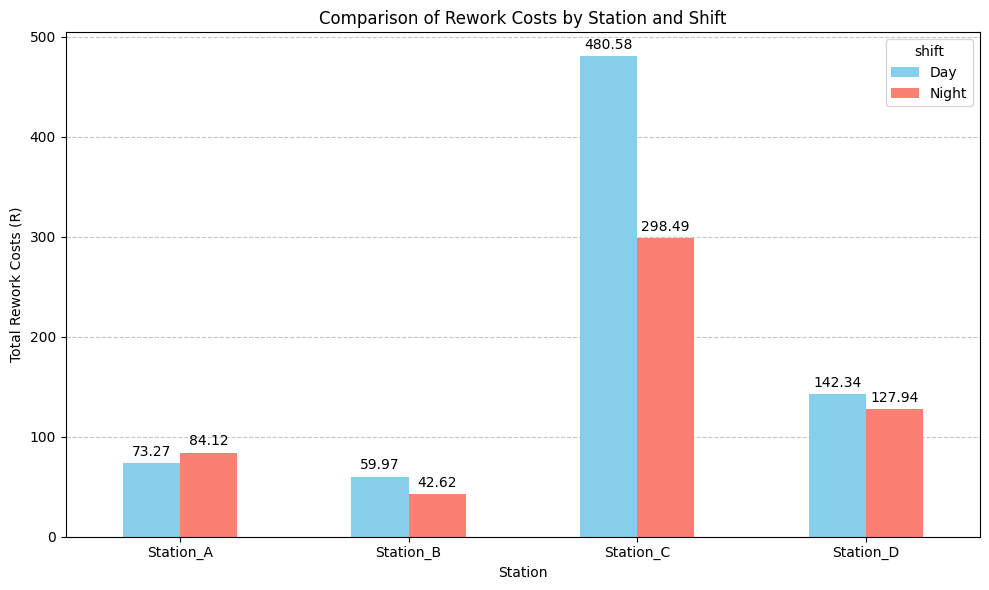

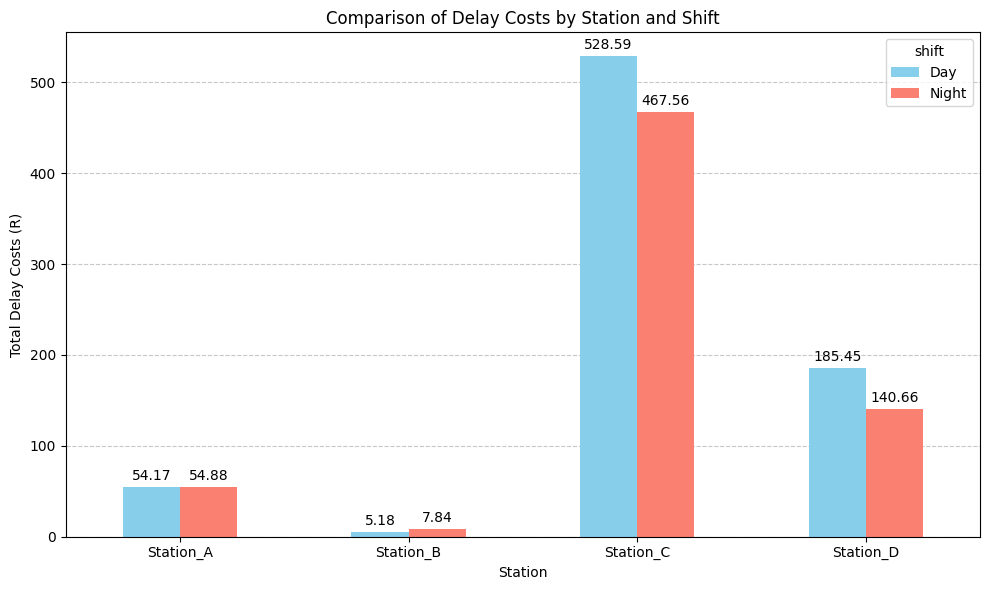

In [53]:

def plot_grouped_shift_costs(df, metric_column, title):
    """
    Plots a grouped bar chart comparing Day vs Night costs per station.
    """
    # Group by station and shift
    pivot_df = df.groupby(['station_id', 'shift'])[metric_column].sum().unstack()
    
    # Plotting
    ax = pivot_df.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'], zorder=2)
    
    plt.title(f"Comparison of {title} by Station and Shift")
    plt.xlabel("Station")
    plt.ylabel(f"Total {title} (R)")
    plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
    plt.xticks(rotation=0)
    
    # Adding labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
        
    plt.tight_layout()
    plt.show()

# Generate the two side-by-side comparison graphs
plot_grouped_shift_costs(df, 'rework_cost', 'Rework Costs')
plot_grouped_shift_costs(df, 'delay_cost', 'Delay Costs')

In [54]:
#finacial impact Analysis

# 1. Group by station and shift to sum costs
summary = df.groupby(['station_id', 'shift'])[['rework_cost', 'delay_cost']].sum()

# 2. Reshape the table to separate Day and Night columns
summary_table = summary.unstack(level='shift')

# 3. Clean up the column names
summary_table.columns = [
    'Rework Cost (Day)', 'Rework Cost (Night)', 
    'Delay Cost (Day)', 'Delay Cost (Night)'
]

# 4. Calculate total costs (Day + Night)
summary_table['Total Rework Cost'] = summary_table['Rework Cost (Day)'] + summary_table['Rework Cost (Night)']
summary_table['Total Delay Cost'] = summary_table['Delay Cost (Day)'] + summary_table['Delay Cost (Night)']

# 5. Calculate shift differences (Day - Night)
# Positive numbers mean Day was more expensive. Negative means Night was more expensive.
summary_table['Rework Shift Diff'] = summary_table['Rework Cost (Day)'] - summary_table['Rework Cost (Night)']
summary_table['Delay Shift Diff'] = summary_table['Delay Cost (Day)'] - summary_table['Delay Cost (Night)']

# 6. Calculate the Grand Total (All costs combined)
summary_table['Grand Total Cost'] = summary_table['Total Rework Cost'] + summary_table['Total Delay Cost']

# Display the final table
print(summary_table)



            Rework Cost (Day)  Rework Cost (Night)  Delay Cost (Day)  \
station_id                                                             
Station_A               73.27                84.12             54.17   
Station_B               59.97                42.62              5.18   
Station_C              480.58               298.49            528.59   
Station_D              142.34               127.94            185.45   

            Delay Cost (Night)  Total Rework Cost  Total Delay Cost  \
station_id                                                            
Station_A                54.88             157.39            109.05   
Station_B                 7.84             102.59             13.02   
Station_C               467.56             779.07            996.15   
Station_D               140.66             270.28            326.11   

            Rework Shift Diff  Delay Shift Diff  Grand Total Cost  
station_id                                                         
Stat

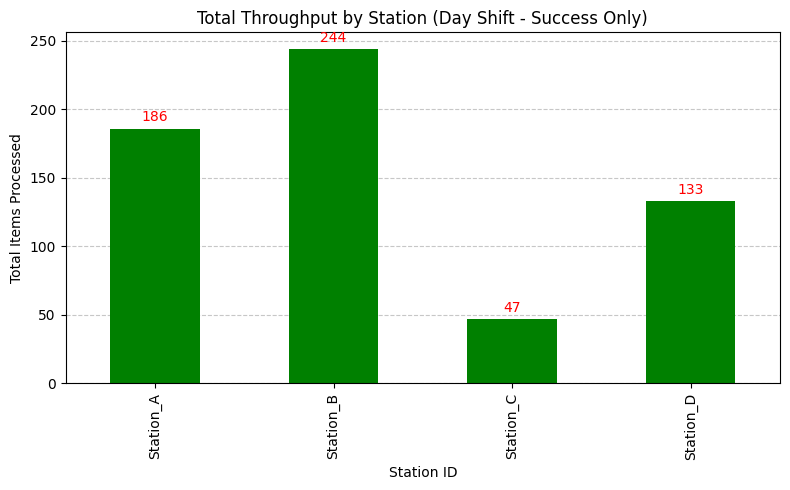

In [55]:
# ThroughPut by station for day shift (success only)
station_throughput_day = df[(df["shift"] == "Day") & (df["status"] == "Success")].groupby("station_id").size()

plt.figure(figsize=(8,5))
station_throughput_day.plot(kind='bar', color='green', zorder=2) 

plt.title("Total Throughput by Station (Day Shift - Success Only)")
plt.xlabel("Station ID")
plt.ylabel("Total Items Processed")  
plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=1)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3, color="red") 

plt.tight_layout()
plt.show()



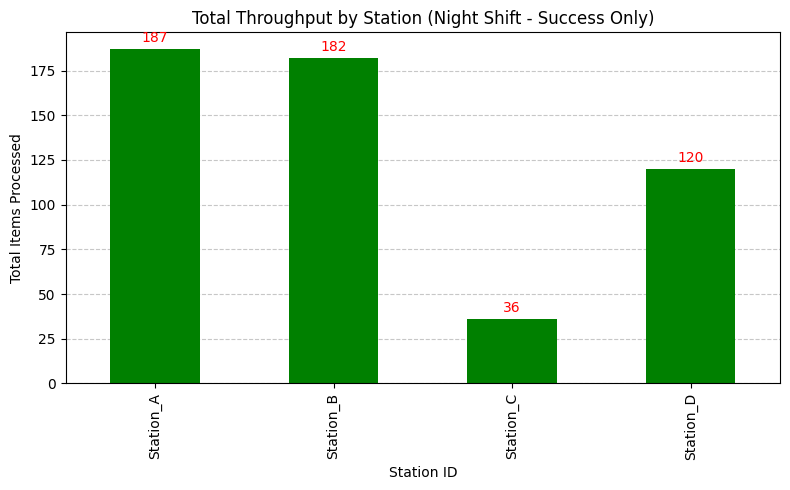

In [56]:
# ThroughPut by station for Night shift (success only)
station_throughput_night = df[(df["shift"] == "Night") & (df["status"] == "Success")].groupby("station_id").size()

plt.figure(figsize=(8,5))
station_throughput_night.plot(kind='bar', color='green', zorder=2) 

plt.title("Total Throughput by Station (Night Shift - Success Only)")
plt.xlabel("Station ID")
plt.ylabel("Total Items Processed")  
plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=1)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3, color="red") 

plt.tight_layout()
plt.show()


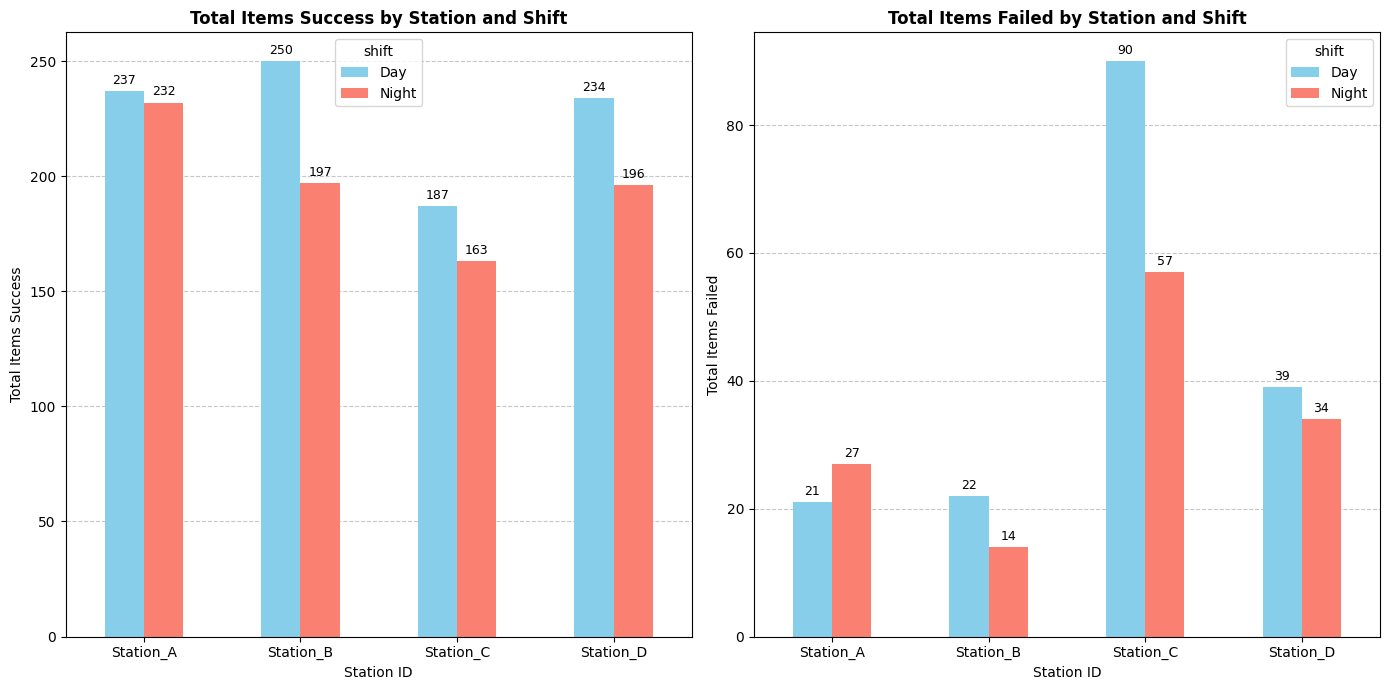

In [57]:

shift_success_count = df[df["defect_flag"] == 0].groupby(["station_id", "shift"]).size().unstack(fill_value=0)
shift_failed_count = df[df["defect_flag"] == 1].groupby(["station_id", "shift"]).size().unstack(fill_value=0)
plt.figure(figsize=(14, 7))

# Success Items
plt.subplot(1, 2, 1)
# kind='bar' creates the bars. unstack makes them double bars.
shift_success_count.plot(kind='bar', ax=plt.gca(), zorder=2,color=['skyblue', 'salmon'])
plt.title("Total Items Success by Station and Shift", fontsize=12, fontweight='bold')
plt.xlabel("Station ID")
plt.ylabel("Total Items Success")  
plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.xticks(rotation=0) # Keeps station names upright

# Add data labels on top of each bar
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3, color="black", fontsize=9) 

# failed items
plt.subplot(1, 2, 2)
shift_failed_count.plot(kind='bar', ax=plt.gca(), zorder=2,color=['skyblue', 'salmon'])
plt.title("Total Items Failed by Station and Shift", fontsize=12, fontweight='bold')
plt.xlabel("Station ID")
plt.ylabel("Total Items Failed")
plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.xticks(rotation=0) # Keeps station names upright

# Add data labels on top of each bar
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3, color="black", fontsize=9) 

# 3. Clean up spacing and display
plt.tight_layout()
plt.show()


In [58]:
financial_summary = df.groupby(['station_id', 'shift']).agg(
    total_rework_cost=('rework_cost', 'sum'),
    total_delay_cost=('delay_cost', 'sum'),
    total_orders=('order_id', 'count'),
    failed_orders=('defect_flag', 'sum')
).reset_index()

financial_summary['total_cost'] = (
    financial_summary['total_rework_cost'] + 
    financial_summary['total_delay_cost']
)

financial_summary['cost_per_order'] = (
    financial_summary['total_cost'] / 
    financial_summary['total_orders']
).round(2)

print(financial_summary.sort_values('total_cost', ascending=False))

  station_id  shift  total_rework_cost  total_delay_cost  total_orders  \
4  Station_C    Day             480.58            528.59           277   
5  Station_C  Night             298.49            467.56           220   
6  Station_D    Day             142.34            185.45           273   
7  Station_D  Night             127.94            140.66           230   
1  Station_A  Night              84.12             54.88           259   
0  Station_A    Day              73.27             54.17           258   
2  Station_B    Day              59.97              5.18           272   
3  Station_B  Night              42.62              7.84           211   

   failed_orders  total_cost  cost_per_order  
4             90     1009.17            3.64  
5             57      766.05            3.48  
6             39      327.79            1.20  
7             34      268.60            1.17  
1             27      139.00            0.54  
0             21      127.44            0.49  
2   

In [59]:
# 1. Calculate the grand total cost for each station
station_totals = df.groupby('station_id')[['rework_cost', 'delay_cost']].sum()
station_totals['Grand Total Cost'] = station_totals['rework_cost'] + station_totals['delay_cost']

# 2. Sort the stations from highest cost to lowest cost
ranked_stations = station_totals.sort_values(by='Grand Total Cost', ascending=False)

# 3. Calculate percentage contribution to total factory loss
total_factory_loss = ranked_stations['Grand Total Cost'].sum()
ranked_stations['% of Total Loss'] = (ranked_stations['Grand Total Cost'] / total_factory_loss) * 100

# Display the ranked table
print("=== STATION RANKING ===")
print(ranked_stations[['rework_cost', 'delay_cost', 'Grand Total Cost', '% of Total Loss']].round(2))


=== STATION RANKING ===
            rework_cost  delay_cost  Grand Total Cost  % of Total Loss
station_id                                                            
Station_C        779.07      996.15           1775.22            64.47
Station_D        270.28      326.11            596.39            21.66
Station_A        157.39      109.05            266.44             9.68
Station_B        102.59       13.02            115.61             4.20


C:\Users\phatu\AppData\Local\Temp\ipykernel_3884\4223170182.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_costs = df.groupby('station_id').apply(


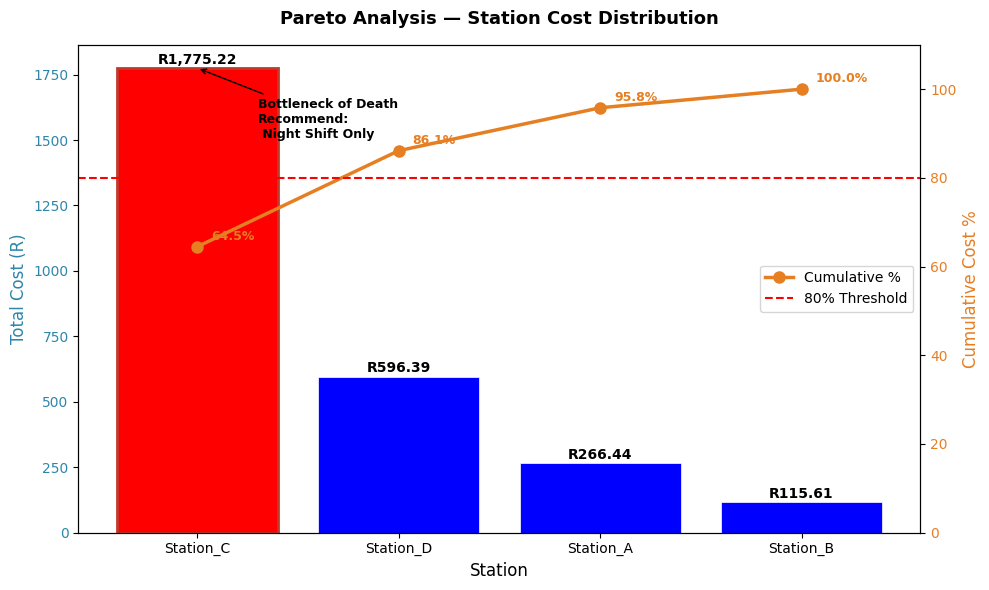


Station Cost Rankings:
station_id  total_cost  cumulative_pct
 Station_C     1775.22       64.467654
 Station_D      596.39       86.125738
 Station_A      266.44       95.801588
 Station_B      115.61      100.000000


In [60]:

import matplotlib.ticker as mticker
# Calculate total cost per station
station_costs = df.groupby('station_id').apply(
    lambda x: x['rework_cost'].sum() + x['delay_cost'].sum()
).reset_index()
station_costs.columns = ['station_id', 'total_cost']

# Sort descending
station_costs = station_costs.sort_values(
    'total_cost', ascending=False
).reset_index(drop=True)

# Calculate cumulative percentage
station_costs['cumulative_pct'] = (
    station_costs['total_cost'].cumsum() / 
    station_costs['total_cost'].sum() * 100
)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart
colors = ['red' if s == 'Station_C' else 'blue' 
          for s in station_costs['station_id']]
bars = ax1.bar(
    station_costs['station_id'],
    station_costs['total_cost'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels on bars
for bar, cost in zip(bars, station_costs['total_cost']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'R{cost:,.2f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax1.set_xlabel('Station', fontsize=12)
ax1.set_ylabel('Total Cost (R)', fontsize=12, color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(
    station_costs['station_id'],
    station_costs['cumulative_pct'],
    color='#E67E22',
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Cumulative %'
)

# Add 80% reference line
ax2.axhline(
    y=80, color='red',
    linestyle='--',
    linewidth=1.5,
    label='80% Threshold'
)

# Add percentage labels on line
for i, pct in enumerate(station_costs['cumulative_pct']):
    ax2.annotate(
        f'{pct:.1f}%',
        xy=(i, pct),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=9,
        color='#E67E22',
        fontweight='bold'
    )

ax2.set_ylabel('Cumulative Cost %', fontsize=12, color='#E67E22')
ax2.tick_params(axis='y', labelcolor='#E67E22')
ax2.set_ylim(0, 110)
ax2.legend(loc='center right', fontsize=10)

# Title and styling
plt.title(
    'Pareto Analysis — Station Cost Distribution',
    fontsize=13, fontweight='bold', pad=15
)

# Highlight Station C
ax1.patches[0].set_edgecolor('#C0392B')
ax1.patches[0].set_linewidth(2)

# Add annotation
ax1.annotate(
    'Bottleneck of Death\nRecommend:\n Night Shift Only',
    xy=(0, station_costs['total_cost'].iloc[0]),
    xytext=(0.3, station_costs['total_cost'].iloc[0] * 0.85),
    fontsize=9,
    color='black',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black')
)

plt.tight_layout()
plt.savefig('pareto_station_costs.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStation Cost Rankings:")
print(station_costs.to_string(index=False))

## Pareto Analysis — The 80/20 Operational Restructuring Plan

The Pareto analysis reveals that Station C is the primary 
cost driver, contributing disproportionately to GlobalLink's 
total operational losses.

### Recommended Restructuring:

| Shift | Stations | Purpose | Expected Outcome |
|-------|----------|---------|-----------------|
| Day (06:00-17:00) | A, B, D | High volume peak operations | 80% capacity at optimal efficiency |
| Night (18:00-05:00) | C | Training + low volume rework | Cost containment + capability building |

### Financial Projection:
- Removing Station C from Day shift eliminates its 
  contribution to peak hour delays
- Night shift training at Station C builds staff capability 
  at lowest operational risk
- Stations A, B, D expanded Day operations absorb 
  redistributed volume with minimal additional cost

### Implementation:
- Week 1-2: Redistribute Station C orders to A, B, D during Day
- Week 3-4: Begin structured training programme at Station C Night
- Month 2: Monitor cost reduction and throughput improvement
- Month 3: Evaluate Station C readiness for Day reintegration

In [61]:
# Current total cost
current_cost = df['rework_cost'].sum() + df['delay_cost'].sum()

# Projected cost after removing Station C from Day shift
# Assume 40% reduction in Station C costs by moving to night
projected_c_reduction = df[
    (df['station_id']=='Station_C') & 
    (df['shift']=='Day')
]['rework_cost'].sum() + df[
    (df['station_id']=='Station_C') & 
    (df['shift']=='Day')
]['delay_cost'].sum() * 0.60  # 60% of Day C costs eliminated

projected_cost = current_cost - projected_c_reduction
savings = current_cost - projected_cost

print(f"Current Monthly Cost: R{current_cost:,.2f}")
print(f"Projected Cost After Restructuring: R{projected_cost:,.2f}")
print(f"Projected Monthly Savings: R{savings:,.2f}")
print(f"Annual Savings Projection: R{savings*12:,.2f}")

Current Monthly Cost: R2,753.66
Projected Cost After Restructuring: R1,955.93
Projected Monthly Savings: R797.73
Annual Savings Projection: R9,572.81


In [62]:
# DEFECT RATE ANALYSIS
# Defect percentage per station per shift
defect_summary = df.groupby(['station_id', 'shift'])['defect_flag'].agg(['sum', 'count']).reset_index()
defect_summary['Defect Percentage'] = (defect_summary['sum'] / defect_summary['count']) * 100
defect_summary.rename(columns={'sum': 'Total Defects', 'count': 'Total Items'}, inplace=True)
print(defect_summary[['station_id', 'shift', 'Total Defects', 'Total Items', 'Defect Percentage']].round(2))

  station_id  shift  Total Defects  Total Items  Defect Percentage
0  Station_A    Day             21          258               8.14
1  Station_A  Night             27          259              10.42
2  Station_B    Day             22          272               8.09
3  Station_B  Night             14          211               6.64
4  Station_C    Day             90          277              32.49
5  Station_C  Night             57          220              25.91
6  Station_D    Day             39          273              14.29
7  Station_D  Night             34          230              14.78


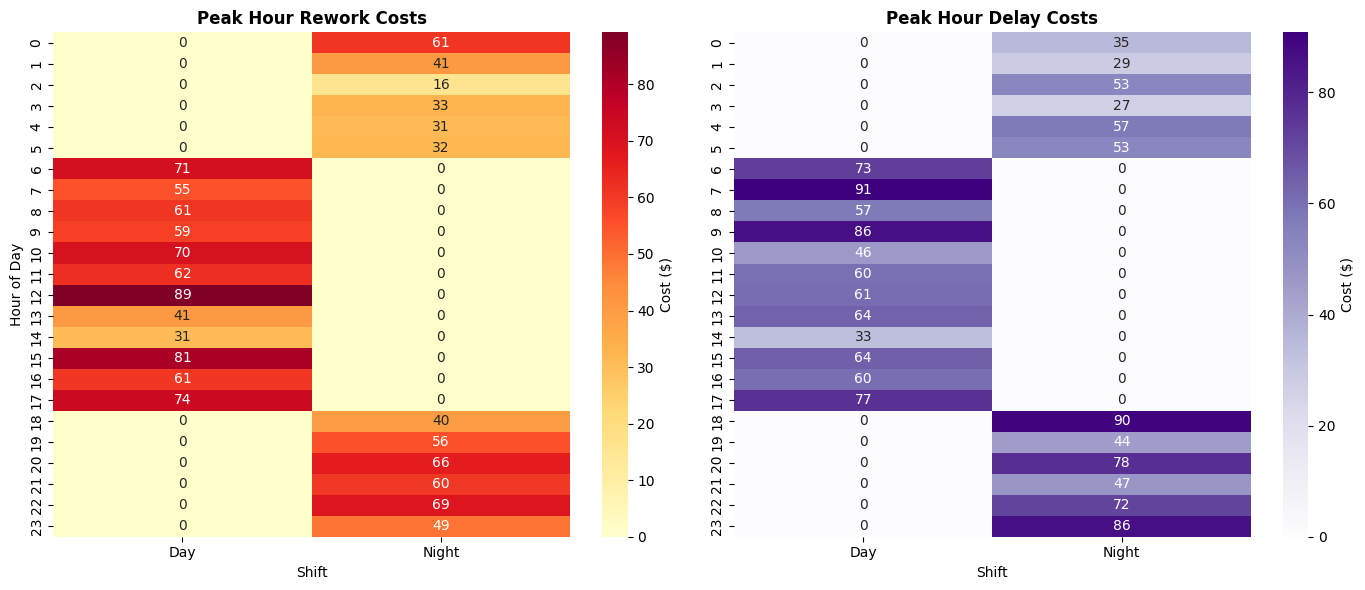

In [63]:
# Peak hour heatmap for rework and delay costs

heatmap_data = df.groupby(['hour', 'shift'])[['rework_cost', 'delay_cost']].sum().unstack(fill_value=0)

# Setup a 1-row, 2-column graph layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Rework Costs on the first board (ax1)
sns.heatmap(heatmap_data['rework_cost'], ax=ax1, cmap='YlOrRd', annot=True, fmt='.0f', cbar_kws={'label': 'Cost ($)'})
ax1.set_title('Peak Hour Rework Costs', fontsize=12, fontweight='bold')
ax1.set_xlabel('Shift')
ax1.set_ylabel('Hour of Day')

# Plot Delay Costs on the second board (ax2)
sns.heatmap(heatmap_data['delay_cost'], ax=ax2, cmap='Purples', annot=True, fmt='.0f', cbar_kws={'label': 'Cost ($)'})
ax2.set_title('Peak Hour Delay Costs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Shift')
ax2.set_ylabel('') # Hide y-label on the right side to keep it clean

plt.tight_layout()
plt.show()


